In [1]:
import os 
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
MASTER_DIR = Path(r"D:\Automotive\Race Strategy Decision Support System (RSDSS)\Race-Strategy-Decision-Support-System-RSDSS-\Data\Processed\Master\Master_Dataset.csv")
df = pd.read_csv(MASTER_DIR)

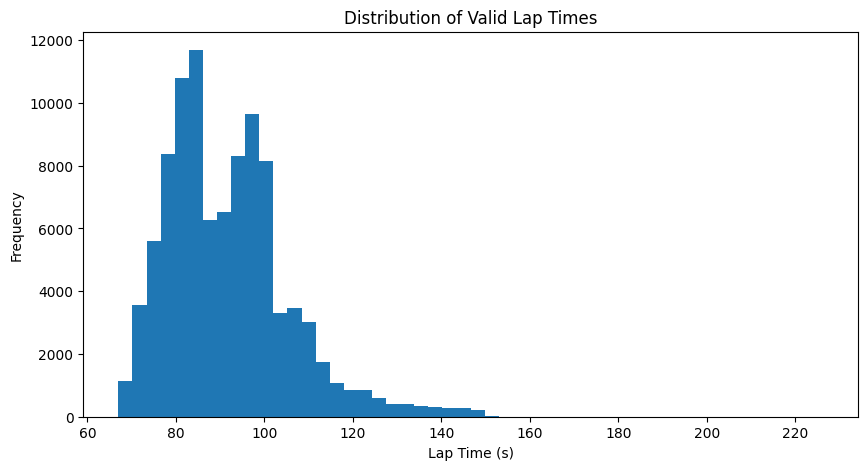

In [3]:
valid_df = df[df["ValidLap"]].copy()
plt.figure(figsize=(10,5))

plt.hist(valid_df["LapTime_Seconds"], bins=50)

plt.xlabel("Lap Time (s)")
plt.ylabel("Frequency")
plt.title("Distribution of Valid Lap Times")

plt.show()

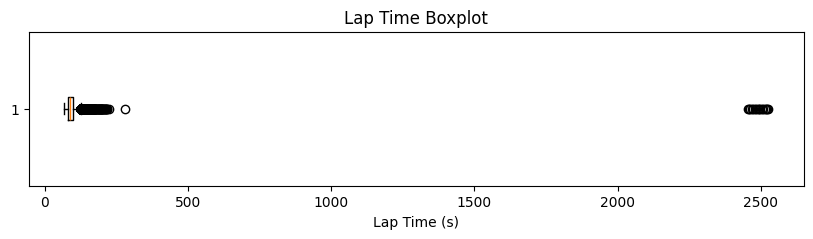

In [4]:
plt.figure(figsize=(10, 2))

plt.boxplot(df["LapTime_Seconds"].dropna(), vert=False)

plt.title("Lap Time Boxplot")
plt.xlabel("Lap Time (s)")

plt.show()

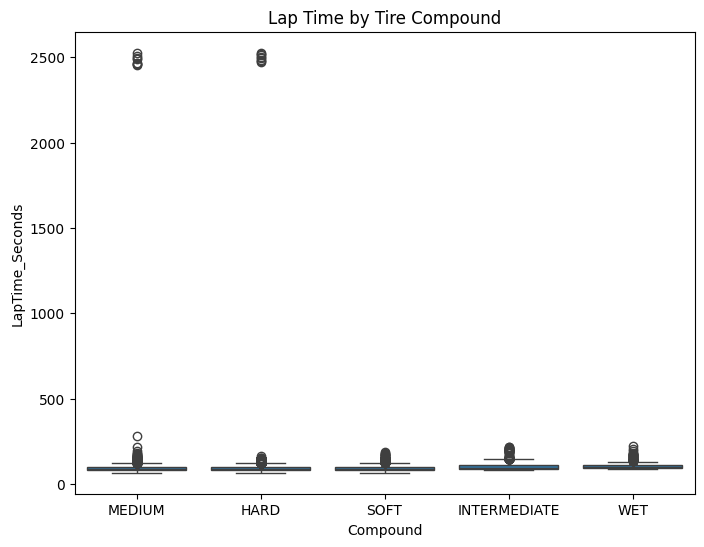

In [5]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Compound",
    y="LapTime_Seconds"
)

plt.title("Lap Time by Tire Compound")

plt.show()

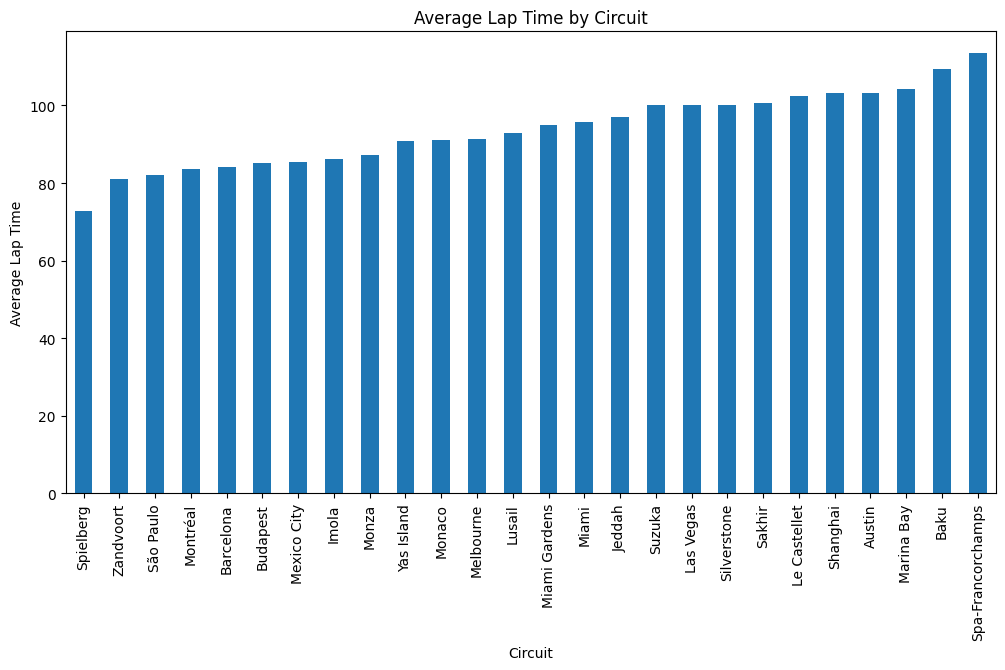

In [6]:
avg = (
    df.groupby("Circuit")["LapTime_Seconds"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

avg.plot(kind="bar")

plt.ylabel("Average Lap Time")

plt.title("Average Lap Time by Circuit")

plt.show()

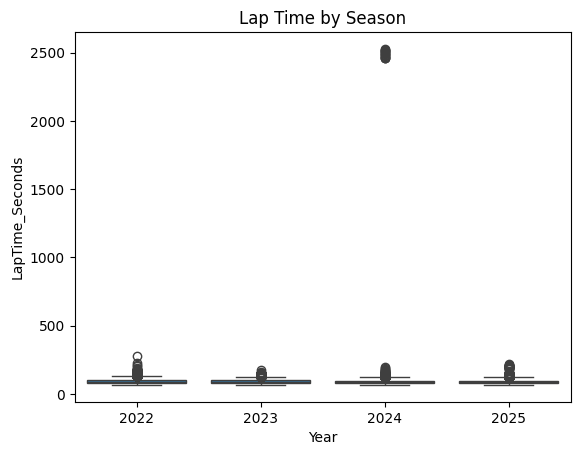

In [7]:
sns.boxplot(
    data=df,
    x="Year",
    y="LapTime_Seconds"
)

plt.title("Lap Time by Season")

plt.show()

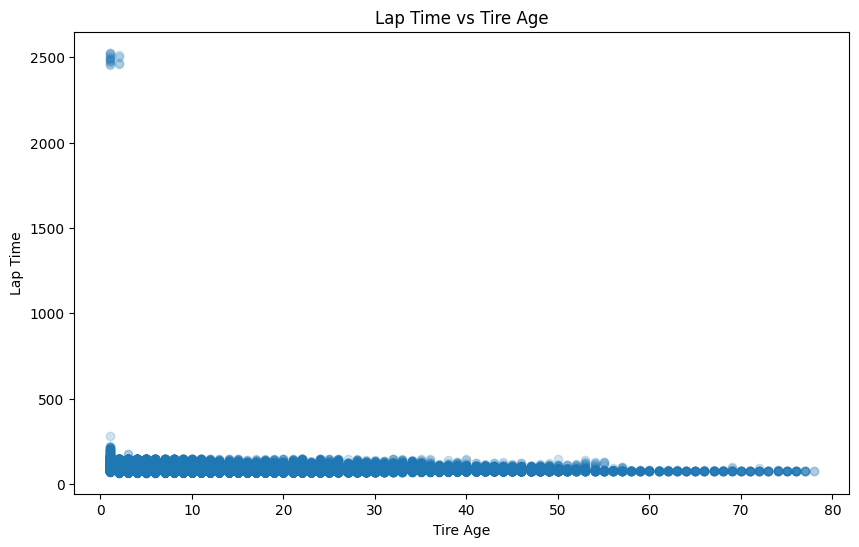

In [8]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["TireAge"],
    df["LapTime_Seconds"],
    alpha=0.2
)

plt.xlabel("Tire Age")

plt.ylabel("Lap Time")

plt.title("Lap Time vs Tire Age")

plt.show()

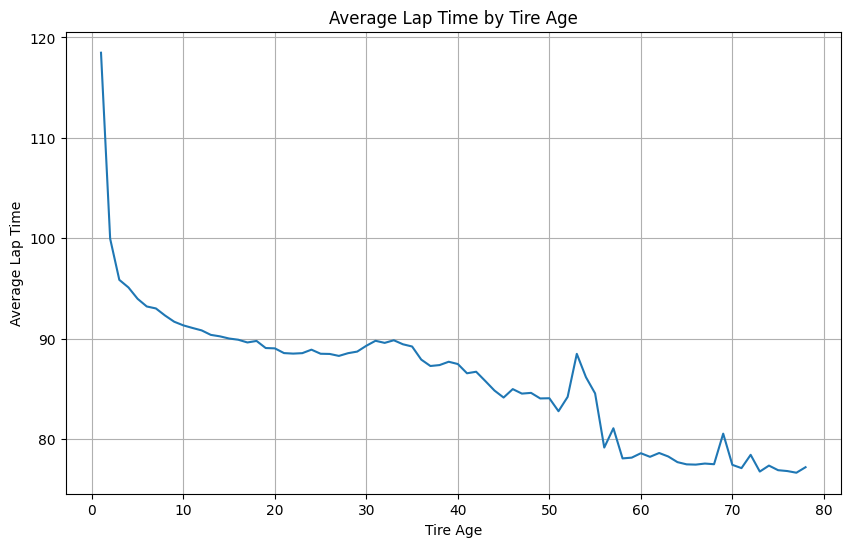

In [9]:
avg = (
    df.groupby("TireAge")["LapTime_Seconds"]
      .mean()
)

plt.figure(figsize=(10,6))

plt.plot(avg.index, avg.values)

plt.xlabel("Tire Age")

plt.ylabel("Average Lap Time")

plt.title("Average Lap Time by Tire Age")

plt.grid(True)

plt.show()

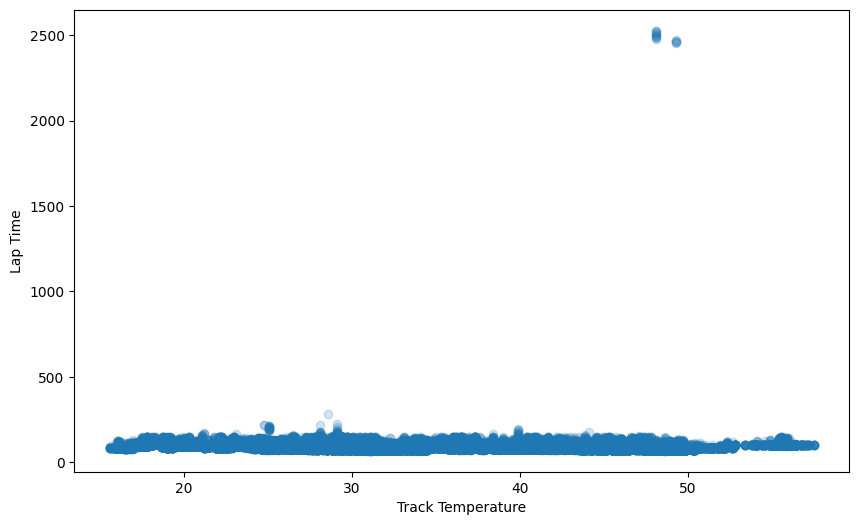

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["TrackTemp"],
    df["LapTime_Seconds"],
    alpha=0.2
)

plt.xlabel("Track Temperature")

plt.ylabel("Lap Time")

plt.show()

In [11]:
corr = (
    df.select_dtypes(include="number")
      .corr()["LapTime_Seconds"]
      .sort_values(ascending=False)
)

corr

LapTime_Seconds    1.000000
Position           0.022752
AirTemp           -0.001041
Year              -0.026820
Stint             -0.053565
TrackTemp         -0.058713
TireAge           -0.108614
LapNumber         -0.124312
Name: LapTime_Seconds, dtype: float64

## Conclusion

- Lap time distributions differ significantly across circuits due to variations in circuit length and characteristics.
- Tire age is associated with a gradual increase in lap time, indicating measurable tire degradation.
- Track temperature appears to influence lap performance, although its effect should be further quantified.
- Tire compound contributes to differences in average lap time and pace consistency.